# Gold fcc111 infinite slab 30 degree boundary

> Willem de Kleijne | March 17, 2026  


In [2]:
import abtem
import numpy as np
import matplotlib.pyplot as plt

## Gold Unitcell

Grain boundary information for rotation axis: 111
Show the sigma values up to 15 (Note: * means twist GB, Theta is the rotation angle)
|  Sigma  |  Theta  | GB plane   | CSL matrix   |
|---------+---------+------------+--------------|
|    3    |   60    | (1 -2 1)   | 1  1  1      |
|         |         | (1 0 -1)   | -2  0  1     |
|         |         | (1 1 1)*   | 1 -1  1      |
|    7    |  38.21  | (1 -3 2)   | 1  5  1      |
|         |         | (5 -1 -4)  | -3 -1  1     |
|         |         | (1 1 1)*   | 2 -4  1      |
|   13    |  27.8   | (1 -4 3)   | 1  7  1      |
|         |         | (7 -2 -5)  | -4 -2  1     |
|         |         | (1 1 1)*   | 3 -5  1      |


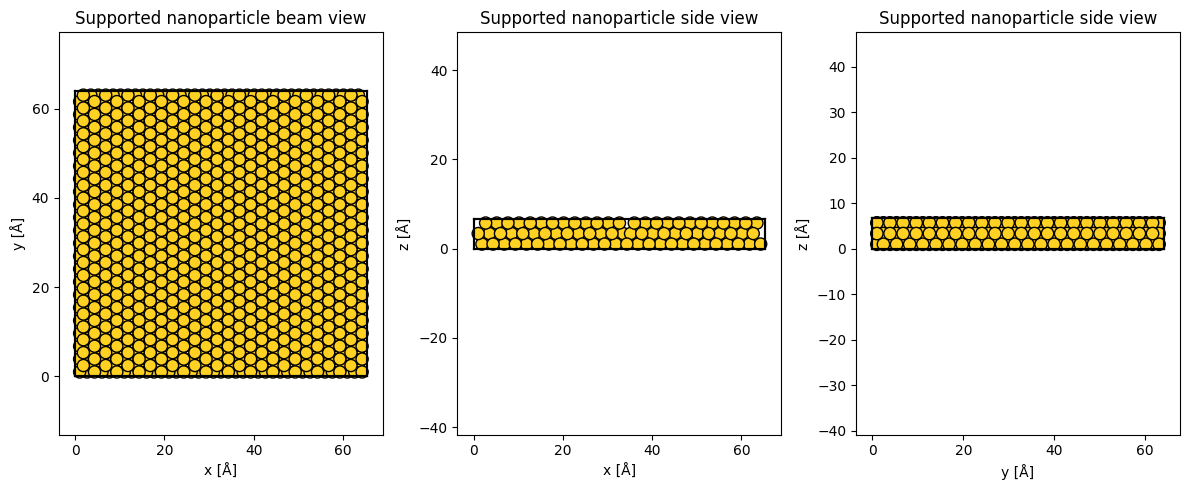

In [4]:
from ase.build import bulk
import aimsgb
import abtem

lc = 4.08
unit_cell = bulk('Au', a=lc, cubic=True)

# --- Check what Σ values are available for [111] ---
print(aimsgb.GBInformation([1,1,1], max_sigma=15))


s_input = aimsgb.Grain.from_ase_atoms(unit_cell)
# GrainBoundary(axis, sigma, plane, grain, uc_a, uc_b)
gb = aimsgb.GrainBoundary([1,1,1], 3, [1,-2,1], s_input, uc_a=4, uc_b=4)

structure = aimsgb.Grain.stack_grains(gb.grain_a, gb.grain_b, direction=gb.direction)

gb_structure = structure.to_ase_atoms()
gb_structure.center()
gb_structure.wrap()

repition = (27,27,1)
gb_structure = gb_structure * repition
mask = (
    (gb_structure.positions[:,2] > -1) & (gb_structure.positions[:,2] < 6)
)
gb_structure = gb_structure[mask]

gb_structure.center(vacuum=1)
pos = gb_structure.positions

x_extent = pos[:, 0].max() - pos[:, 0].min()
y_extent = pos[:, 1].max() - pos[:, 1].min()
z_extent = pos[:, 2].max() - pos[:, 2].min()

del gb_structure[gb_structure.positions[:,0] > x_extent/2+32]
del gb_structure[gb_structure.positions[:,1] > y_extent/2+32]
del gb_structure[gb_structure.positions[:,0] < x_extent/2-32]
del gb_structure[gb_structure.positions[:,1] < y_extent/2-32]
gb_structure.center(vacuum=1)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))
abtem.show_atoms(
    gb_structure ,
    ax=ax1,
    title="Supported nanoparticle beam view",
    merge=0.1,
    scale=1,
)
abtem.show_atoms(
    gb_structure ,
    ax=ax2,
    plane="xz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.1,
)
abtem.show_atoms(
    gb_structure ,
    ax=ax3,
    plane="yz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.1,
)
fig.tight_layout();

## Potential 

We build the numeric representation of the atomic potentials.

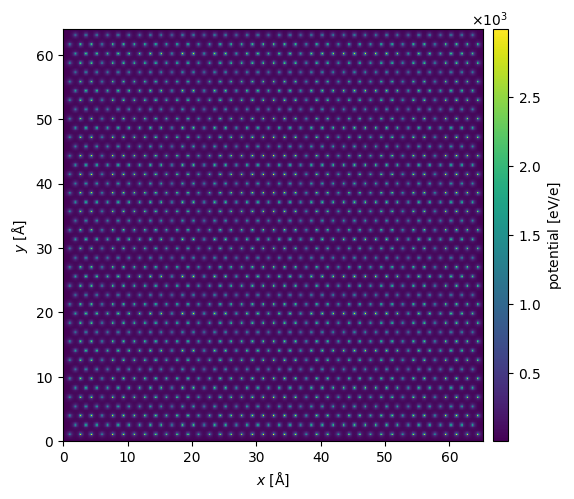

In [5]:
potential = abtem.Potential(
    gb_structure,
    gpts=(512,512),         # to ensure that the size of diffraction pattern is 512x512
    slice_thickness= lc/8,
    device='cpu',
).build(
    lazy=False
)

potential.show(
    cbar=True
);

## Probe

We use a converged probe with a few different aberrations.

tasks:   0%|          | 0/2 [00:00<?, ?it/s]

tasks:   0%|          | 0/2 [00:00<?, ?it/s]

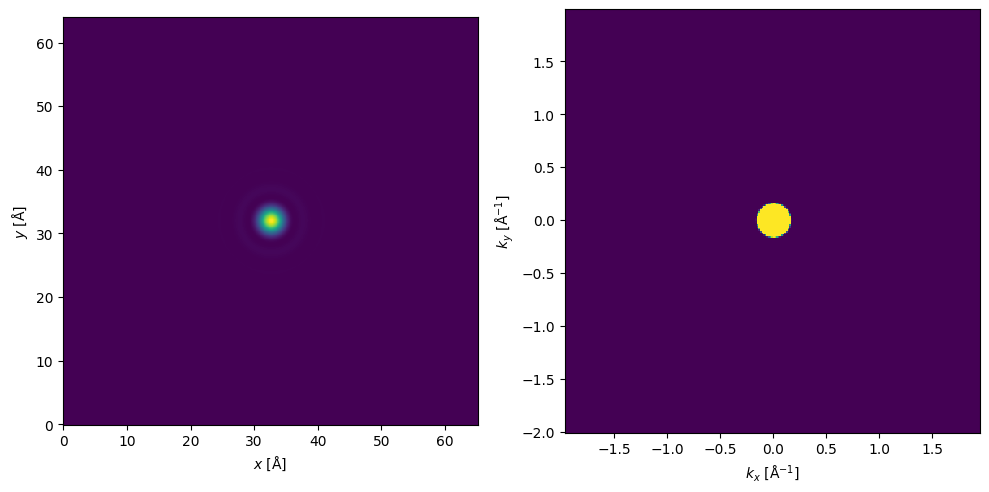

In [6]:
energy = 10e3 # eV
semiangle_cutoff = 20 # mrad


aberrations = {
    "C10":0,
}

probes = abtem.Probe(
    energy=energy,
    semiangle_cutoff=semiangle_cutoff,
    aberrations=aberrations,
    device='cpu',
).match_grid(
    potential
)

fig, axs = plt.subplots(1,2,figsize=(10,5))
probes.show(ax=axs[0])
probes.build().diffraction_patterns(max_angle=None).crop(gpts=(256,256)).show(ax=axs[1])
fig.tight_layout()

## Simulations

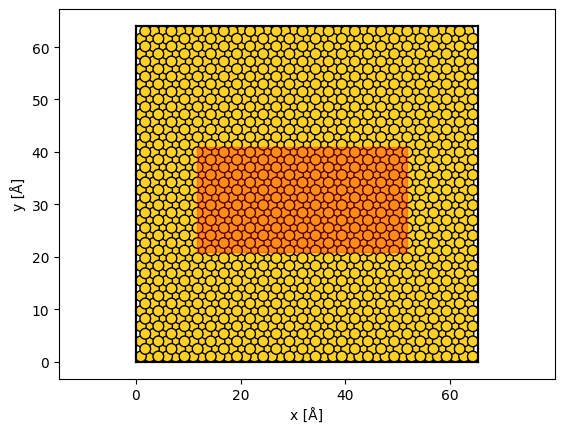

In [7]:
pos = gb_structure.positions

x_extent = pos[:, 0].max() - pos[:, 0].min()
y_extent = pos[:, 1].max() - pos[:, 1].min()

grid_scan = abtem.GridScan(
    start = (x_extent/2-20, y_extent/2-10),
    end = (x_extent/2+20, y_extent/2+10),
    gpts=(48+1,24+1),
    endpoint=True
)

fig,ax = plt.subplots()
abtem.show_atoms(gb_structure,ax=ax)
grid_scan.add_to_plot(ax)

detector = abtem.PixelatedDetector(
    max_angle=None
)

In [9]:
measurement = probes.scan(
    potential,
    grid_scan,
    detector,
).compute(
)
dose = 1e7
measurement_noisy = measurement.crop(gpts=(256,256)).poisson_noise(dose)

tasks:   0%|          | 0/30 [00:00<?, ?it/s]

In [10]:
dataset_noisy = measurement_noisy.to_quantem()
dataset_noisy

Dataset(shape=(49, 25, 256, 256), dtype=float32, name='DiffractionPatterns')
  sampling: [0.83333333 0.83333333 0.01531515 0.01561831]
  units: ['A', 'A', 'A^-1', 'A^-1']
  signal units: 'arb. units'

In [11]:
dataset_noisy.save(f"/home/wdekleijne/git-repos/willem-playground/data/twin_1-21_60deg_{semiangle_cutoff}mrad_{energy:.1e}kev_{dose:.0e}-dose_3_layer_256x256.zip",mode='o')

## Ensure that you get what happens in the creation of the boundary

Grain boundary information for rotation axis: 111
Show the sigma values up to 15 (Note: * means twist GB, Theta is the rotation angle)
|  Sigma  |  Theta  | GB plane   | CSL matrix   |
|---------+---------+------------+--------------|
|    3    |   60    | (1 -2 1)   | 1  1  1      |
|         |         | (1 0 -1)   | -2  0  1     |
|         |         | (1 1 1)*   | 1 -1  1      |
|    7    |  38.21  | (1 -3 2)   | 1  5  1      |
|         |         | (5 -1 -4)  | -3 -1  1     |
|         |         | (1 1 1)*   | 2 -4  1      |
|   13    |  27.8   | (1 -4 3)   | 1  7  1      |
|         |         | (7 -2 -5)  | -4 -2  1     |
|         |         | (1 1 1)*   | 3 -5  1      |
Atom x extent: 1.6657 Å
Atom y extent: 1.4425 Å
Atom z extent: 54.1785 Å


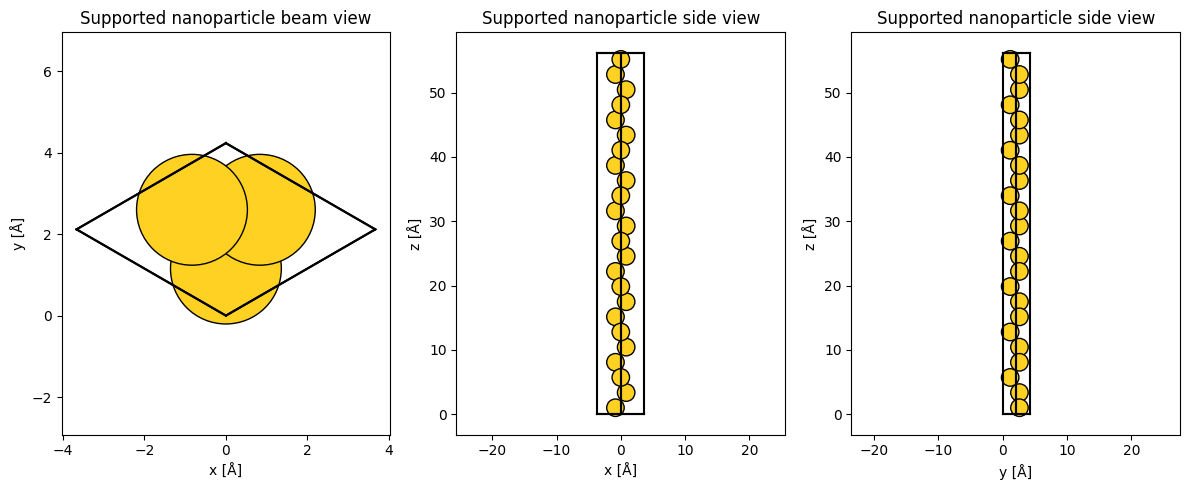

In [15]:
from ase.build import bulk
import aimsgb
import abtem

lc = 4.08
unit_cell = bulk('Au', a=lc, cubic=True)

# --- Check what Σ values are available for [111] ---
print(aimsgb.GBInformation([1,1,1], max_sigma=15))

# --- Build Σ3 [111] grain boundary ---
# GrainBoundary(rotation_axis, sigma, gb_plane, grain, uc_a, uc_b)
#   rotation_axis = [1,1,1]  → rotate around the [111] axis
#   sigma = 3                → Σ3 (60° misorientation)
#   gb_plane = [1,1,1]       → boundary plane is (111) — a twin boundary
#   uc_a, uc_b               → how many unit cells each grain has

s_input = aimsgb.Grain.from_ase_atoms(unit_cell)
# GrainBoundary(axis, sigma, plane, grain, uc_a, uc_b)
gb = aimsgb.GrainBoundary([1,1,1], 3, [1,1,1], s_input, uc_a=4, uc_b=4)

structure = aimsgb.Grain.stack_grains(gb.grain_a, gb.grain_b, direction=gb.direction)

gb_structure = structure.to_ase_atoms()
gb_structure.center()
gb_structure.wrap()

# abtem.show_atoms(gb_structure * repition, plane='yz', scale=0.5)
repition = (1,1,1)
gb_structure = gb_structure * repition
# mask = (
#     (gb_structure.positions[:,2] > -1) & (gb_structure.positions[:,2] < 6)
# )
# gb_structure = gb_structure[mask]

gb_structure.center(vacuum=1)
pos = gb_structure.positions

x_extent = pos[:, 0].max() - pos[:, 0].min()
y_extent = pos[:, 1].max() - pos[:, 1].min()
z_extent = pos[:, 2].max() - pos[:, 2].min()

print(f"Atom x extent: {x_extent:.4f} Å")
print(f"Atom y extent: {y_extent:.4f} Å")
print(f"Atom z extent: {z_extent:.4f} Å")
# del gb_structure[gb_structure.positions[:,0] > x_extent/2+32]
# del gb_structure[gb_structure.positions[:,1] > y_extent/2+32]
# del gb_structure[gb_structure.positions[:,0] < x_extent/2-32]
# del gb_structure[gb_structure.positions[:,1] < y_extent/2-32]
gb_structure.center(vacuum=1)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))
abtem.show_atoms(
    gb_structure ,
    ax=ax1,
    title="Supported nanoparticle beam view",
    merge=0.1,
    scale=1,
)
abtem.show_atoms(
    gb_structure ,
    ax=ax2,
    plane="xz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.1,
)
abtem.show_atoms(
    gb_structure ,
    ax=ax3,
    plane="yz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.1,
)
fig.tight_layout();

## Notice that in the image above the orientation reverses around z = 27 A, but also notice that every individual layer is a perfect hexagonal crystal

Grain boundary information for rotation axis: 111
Show the sigma values up to 15 (Note: * means twist GB, Theta is the rotation angle)
|  Sigma  |  Theta  | GB plane   | CSL matrix   |
|---------+---------+------------+--------------|
|    3    |   60    | (1 -2 1)   | 1  1  1      |
|         |         | (1 0 -1)   | -2  0  1     |
|         |         | (1 1 1)*   | 1 -1  1      |
|    7    |  38.21  | (1 -3 2)   | 1  5  1      |
|         |         | (5 -1 -4)  | -3 -1  1     |
|         |         | (1 1 1)*   | 2 -4  1      |
|   13    |  27.8   | (1 -4 3)   | 1  7  1      |
|         |         | (7 -2 -5)  | -4 -2  1     |
|         |         | (1 1 1)*   | 3 -5  1      |


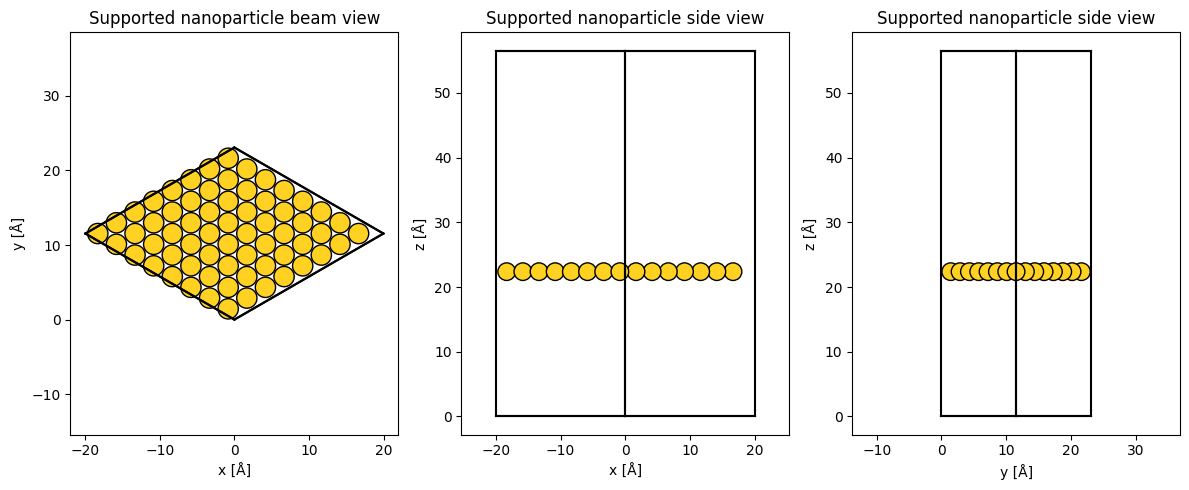

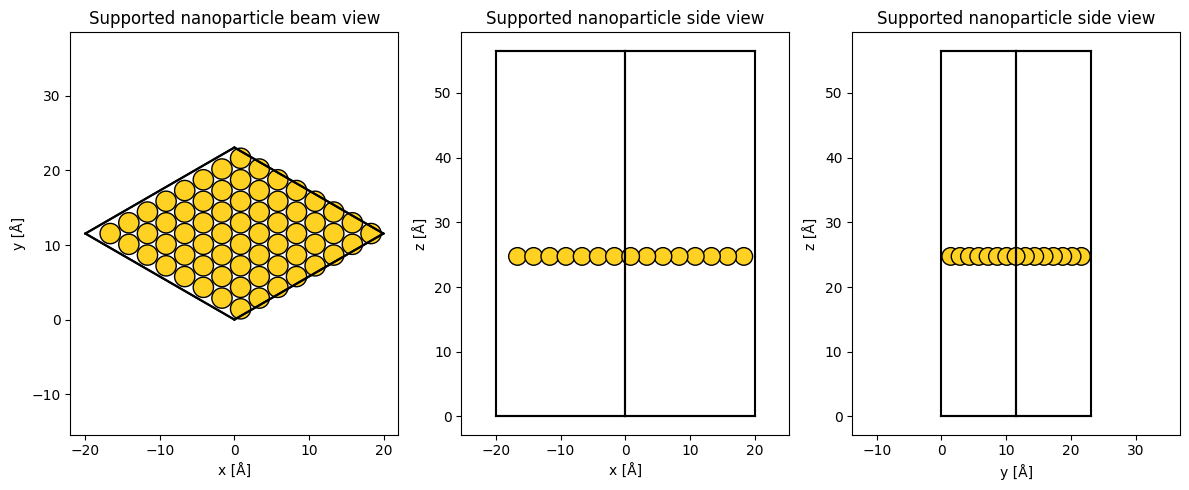

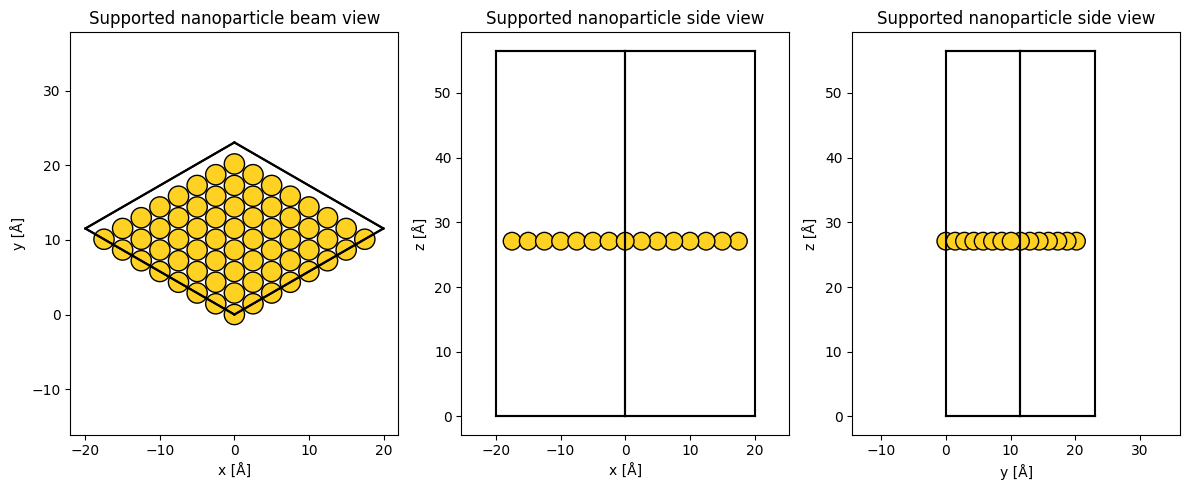

In [22]:
lc = 4.08
unit_cell = bulk('Au', a=lc, cubic=True)

# --- Check what Σ values are available for [111] ---
print(aimsgb.GBInformation([1,1,1], max_sigma=15))

# --- Build Σ3 [111] grain boundary ---
# GrainBoundary(rotation_axis, sigma, gb_plane, grain, uc_a, uc_b)
#   rotation_axis = [1,1,1]  → rotate around the [111] axis
#   sigma = 3                → Σ3 (60° misorientation)
#   gb_plane = [1,1,1]       → boundary plane is (111) — a twin boundary
#   uc_a, uc_b               → how many unit cells each grain has

s_input = aimsgb.Grain.from_ase_atoms(unit_cell)
# GrainBoundary(axis, sigma, plane, grain, uc_a, uc_b)
gb = aimsgb.GrainBoundary([1,1,1], 3, [1,1,1], s_input, uc_a=4, uc_b=4)

structure = aimsgb.Grain.stack_grains(gb.grain_a, gb.grain_b, direction=gb.direction)

gb_structure = structure.to_ase_atoms()
gb_structure.center()
gb_structure.wrap()

# abtem.show_atoms(gb_structure * repition, plane='yz', scale=0.5)
repition = (8,8,1)
gb_structure = gb_structure * repition
mask = (
    (gb_structure.positions[:,2] > 22) & (gb_structure.positions[:,2] < 24)
)
gb_structure_masked = gb_structure[mask]



fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))
abtem.show_atoms(
    gb_structure_masked ,
    ax=ax1,
    title="Supported nanoparticle beam view",
    merge=0.1,
    scale=1,
)
abtem.show_atoms(
    gb_structure_masked ,
    ax=ax2,
    plane="xz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.1,
)
abtem.show_atoms(
    gb_structure_masked ,
    ax=ax3,
    plane="yz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.1,
)
fig.tight_layout();

mask = (
    (gb_structure.positions[:,2] > 24) & (gb_structure.positions[:,2] < 26)
)
gb_structure_masked = gb_structure[mask]



fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))
abtem.show_atoms(
    gb_structure_masked ,
    ax=ax1,
    title="Supported nanoparticle beam view",
    merge=0.1,
    scale=1,
)
abtem.show_atoms(
    gb_structure_masked ,
    ax=ax2,
    plane="xz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.1,
)
abtem.show_atoms(
    gb_structure_masked ,
    ax=ax3,
    plane="yz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.1,
)
fig.tight_layout();

mask = (
    (gb_structure.positions[:,2] > 26) & (gb_structure.positions[:,2] < 28)
)
gb_structure_masked = gb_structure[mask]



fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))
abtem.show_atoms(
    gb_structure_masked ,
    ax=ax1,
    title="Supported nanoparticle beam view",
    merge=0.1,
    scale=1,
)
abtem.show_atoms(
    gb_structure_masked ,
    ax=ax2,
    plane="xz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.1,
)
abtem.show_atoms(
    gb_structure_masked ,
    ax=ax3,
    plane="yz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.1,
)
fig.tight_layout();